# Figure S02 final source rebuild

Run top-to-bottom. This notebook rebuilds the two spatial comparison panels used for Figure S02.

Only slide **004** is plotted, for **DC** and **CD8+ T**. Nearest-neighbor matching to the HuBMAP reference and Leiden-cluster cell-type assignment are calculated once and reused for both panels.


## 1. Configure source inputs and analysis settings

The same three segmentation methods used in the Figure S02 panels are included before and after compensation. HuBMAP expert annotations provide the reference cell locations and cell types.


In [1]:

# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from sklearn.neighbors import NearestNeighbors


In [2]:

# ============================================================
# FILE LOCATIONS
# ============================================================

BASE_DIR = Path(
    "/mnt/jwh83-data/Confetti/output/Redsea/Clustering"
)

HUBMAP_FILE = Path(
    "/mnt/jwh83-data/Confetti/output/"
    "20260130_HuBMAP_Yang_annotate_with_area.h5ad"
)

FOCUS_FILES = {
    "Mesmer - Before REDSEA": (
        "mesmer_beforeREDSEA_leiden.h5ad"
    ),
    "Mesmer - After REDSEA": (
        "mesmer_afterREDSEA_leiden.h5ad"
    ),
    "CellposeV3 - Before REDSEA": (
        "cellpose_cyto3_beforeREDSEA_leiden.h5ad"
    ),
    "CellposeV3 - After REDSEA": (
        "cellpose_cyto3_afterREDSEA_leiden.h5ad"
    ),
    "CellposeSAM - Before REDSEA": (
        "cellposeSAM_beforeREDSEA_leiden.h5ad"
    ),
    "CellposeSAM - After REDSEA": (
        "cellposeSAM_afterREDSEA_leiden.h5ad"
    ),
}


In [3]:

# ============================================================
# ANALYSIS SETTINGS
# ============================================================

MAX_NN_DISTANCE = 10
SWAP_HUBMAP_XY = True

HUBMAP_CELLTYPE_COL = "cell_type_update"
HUBMAP_SLIDE_COL = "sample_ID"

SEGMENTATION_SLIDE_COL = "slide_name"
LEIDEN_COL = "leiden"

HUBMAP_X_COL = "x"
HUBMAP_Y_COL = "y"

SEGMENTATION_X_COL = "x_centroid"
SEGMENTATION_Y_COL = "y_centroid"

ALGORITHM_ORDER = [
    "Mesmer",
    "CellposeSAM",
    "CellposeV3",
]

CONDITION_ORDER = [
    "Before",
    "After",
]

SLIDES_TO_PLOT = [
    "B004-A-004",
]

CELL_TYPES_TO_PLOT = [
    "DC",
    "CD8+ T",
]

# False reproduces the supplied plotting code:
# all segmentation cells receive their cluster-derived label,
# even if that cell's nearest HuBMAP match exceeds 10 pixels.
USE_ONLY_WITHIN_RADIUS = False


## 2. Shared HuBMAP matching and Leiden-cluster labeling

Each segmentation cell is matched to its nearest HuBMAP cell within the same slide. The 10-pixel threshold is used to determine which matches contribute to assigning a dominant HuBMAP cell type to each Leiden cluster.

The matching is performed once for all six before/after files. The resulting cluster labels are then reused for both Figure S02 panels.


In [4]:

# ============================================================
# NEAREST-NEIGHBOR MATCHING
# ============================================================

def build_nearest_neighbor_celltype_matches(
    focus_files=FOCUS_FILES,
    hubmap_file=HUBMAP_FILE,
    hubmap_celltype_col=HUBMAP_CELLTYPE_COL,
    hubmap_slide_col=HUBMAP_SLIDE_COL,
    segmentation_slide_col=SEGMENTATION_SLIDE_COL,
    leiden_col=LEIDEN_COL,
    hubmap_x_col=HUBMAP_X_COL,
    hubmap_y_col=HUBMAP_Y_COL,
    segmentation_x_col=SEGMENTATION_X_COL,
    segmentation_y_col=SEGMENTATION_Y_COL,
    max_nn_distance=MAX_NN_DISTANCE,
    swap_hubmap_xy=SWAP_HUBMAP_XY,
):
    adata_hub = sc.read_h5ad(
        hubmap_file
    )

    required_hub_cols = [
        hubmap_celltype_col,
        hubmap_slide_col,
        hubmap_x_col,
        hubmap_y_col,
    ]

    missing_hub_cols = [
        column
        for column in required_hub_cols
        if column not in adata_hub.obs.columns
    ]

    if missing_hub_cols:
        raise ValueError(
            "HuBMAP file is missing obs columns: "
            f"{missing_hub_cols}"
        )

    hub_obs = adata_hub.obs[
        required_hub_cols
    ].copy()

    hub_obs[hubmap_x_col] = pd.to_numeric(
        hub_obs[hubmap_x_col],
        errors="coerce",
    )

    hub_obs[hubmap_y_col] = pd.to_numeric(
        hub_obs[hubmap_y_col],
        errors="coerce",
    )

    hub_obs[hubmap_slide_col] = (
        hub_obs[hubmap_slide_col]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )

    hub_obs[hubmap_celltype_col] = (
        hub_obs[hubmap_celltype_col]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )

    hub_obs["hubmap_x_original"] = (
        hub_obs[hubmap_x_col]
    )

    hub_obs["hubmap_y_original"] = (
        hub_obs[hubmap_y_col]
    )

    if swap_hubmap_xy:
        hub_obs["hubmap_x_used"] = (
            hub_obs[hubmap_y_col]
        )

        hub_obs["hubmap_y_used"] = (
            hub_obs[hubmap_x_col]
        )

    else:
        hub_obs["hubmap_x_used"] = (
            hub_obs[hubmap_x_col]
        )

        hub_obs["hubmap_y_used"] = (
            hub_obs[hubmap_y_col]
        )

    hub_obs = hub_obs.dropna(
        subset=[
            "hubmap_x_used",
            "hubmap_y_used",
        ]
    ).copy()

    matched_rows = []

    for method, filename in focus_files.items():
        filepath = BASE_DIR / filename

        if not filepath.exists():
            raise FileNotFoundError(
                f"File not found for {method}: "
                f"{filepath}"
            )

        adata = sc.read_h5ad(
            filepath
        )

        required_segmentation_cols = [
            segmentation_x_col,
            segmentation_y_col,
            segmentation_slide_col,
            leiden_col,
        ]

        missing_segmentation_cols = [
            column
            for column in required_segmentation_cols
            if column not in adata.obs.columns
        ]

        if missing_segmentation_cols:
            raise ValueError(
                f"{method} is missing obs columns: "
                f"{missing_segmentation_cols}"
            )

        segmentation_obs = adata.obs[
            required_segmentation_cols
        ].copy()

        segmentation_obs[
            segmentation_x_col
        ] = pd.to_numeric(
            segmentation_obs[
                segmentation_x_col
            ],
            errors="coerce",
        )

        segmentation_obs[
            segmentation_y_col
        ] = pd.to_numeric(
            segmentation_obs[
                segmentation_y_col
            ],
            errors="coerce",
        )

        segmentation_obs[
            segmentation_slide_col
        ] = (
            segmentation_obs[
                segmentation_slide_col
            ]
            .astype("object")
            .fillna("Unknown")
            .astype(str)
        )

        segmentation_obs[
            leiden_col
        ] = (
            segmentation_obs[
                leiden_col
            ]
            .astype("object")
            .fillna("Unknown")
            .astype(str)
        )

        segmentation_obs = (
            segmentation_obs.dropna(
                subset=[
                    segmentation_x_col,
                    segmentation_y_col,
                ]
            ).copy()
        )

        for slide in sorted(
            segmentation_obs[
                segmentation_slide_col
            ].unique()
        ):
            segmentation_slide = (
                segmentation_obs[
                    segmentation_obs[
                        segmentation_slide_col
                    ] == slide
                ].copy()
            )

            hubmap_slide = hub_obs[
                hub_obs[
                    hubmap_slide_col
                ] == slide
            ].copy()

            if hubmap_slide.empty:
                continue

            nearest_neighbors = (
                NearestNeighbors(
                    n_neighbors=1
                )
            )

            nearest_neighbors.fit(
                hubmap_slide[
                    [
                        "hubmap_x_used",
                        "hubmap_y_used",
                    ]
                ].to_numpy()
            )

            distances, indices = (
                nearest_neighbors.kneighbors(
                    segmentation_slide[
                        [
                            segmentation_x_col,
                            segmentation_y_col,
                        ]
                    ].to_numpy()
                )
            )

            distances = distances[:, 0]
            indices = indices[:, 0]

            matched_hubmap_cells = (
                hubmap_slide.iloc[
                    indices
                ].copy()
            )

            slide_matches = pd.DataFrame(
                {
                    "method": method,
                    "file": filename,
                    "slide": slide,
                    "seg_cell": (
                        segmentation_slide.index
                        .to_numpy()
                    ),
                    "seg_leiden": (
                        segmentation_slide[
                            leiden_col
                        ].to_numpy()
                    ),
                    "seg_x_centroid": (
                        segmentation_slide[
                            segmentation_x_col
                        ].to_numpy()
                    ),
                    "seg_y_centroid": (
                        segmentation_slide[
                            segmentation_y_col
                        ].to_numpy()
                    ),
                    "true_cell_type": (
                        matched_hubmap_cells[
                            hubmap_celltype_col
                        ].to_numpy()
                    ),
                    "nn_distance": distances,
                    "within_radius": (
                        distances
                        <= max_nn_distance
                    ),
                }
            )

            matched_rows.append(
                slide_matches
            )

        del adata

    if not matched_rows:
        raise ValueError(
            "No segmentation cells could be "
            "matched to HuBMAP."
        )

    matched_cells_df = pd.concat(
        matched_rows,
        ignore_index=True,
    )

    matched_cells_df[
        "true_cell_type"
    ] = (
        matched_cells_df[
            "true_cell_type"
        ]
        .astype("object")
        .fillna("Unknown")
        .astype(str)
    )

    matched_cells_df[
        "seg_leiden"
    ] = (
        matched_cells_df[
            "seg_leiden"
        ].astype(str)
    )

    matched_cells_df[
        "slide"
    ] = (
        matched_cells_df[
            "slide"
        ].astype(str)
    )

    hub_reference_df = (
        hub_obs[
            [
                hubmap_slide_col,
                hubmap_celltype_col,
                "hubmap_x_used",
                "hubmap_y_used",
            ]
        ]
        .rename(
            columns={
                hubmap_slide_col: "slide",
                hubmap_celltype_col: (
                    "true_cell_type"
                ),
                "hubmap_x_used": "plot_x",
                "hubmap_y_used": "plot_y",
            }
        )
        .copy()
    )

    hub_reference_df["slide"] = (
        hub_reference_df["slide"]
        .astype(str)
    )

    return (
        matched_cells_df,
        hub_reference_df,
    )


In [5]:

# ============================================================
# DOMINANT CELL TYPE PER LEIDEN CLUSTER
# ============================================================

def calculate_dominant_cell_type_per_cluster(
    matched_cells_df,
):
    scored_cells_df = matched_cells_df[
        matched_cells_df["within_radius"]
    ].copy()

    if scored_cells_df.empty:
        raise ValueError(
            "No segmentation cells were within "
            "the matching distance."
        )

    cluster_celltype_counts_df = (
        scored_cells_df
        .groupby(
            [
                "method",
                "file",
                "seg_leiden",
                "true_cell_type",
            ],
            as_index=False,
        )
        .agg(
            cell_count=(
                "seg_cell",
                "size",
            ),
        )
    )

    cluster_celltype_counts_df = (
        cluster_celltype_counts_df
        .sort_values(
            [
                "method",
                "file",
                "seg_leiden",
                "cell_count",
                "true_cell_type",
            ],
            ascending=[
                True,
                True,
                True,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    dominant_cell_types_df = (
        cluster_celltype_counts_df
        .drop_duplicates(
            subset=[
                "method",
                "file",
                "seg_leiden",
            ],
            keep="first",
        )
        .rename(
            columns={
                "seg_leiden": "leiden",
                "true_cell_type": (
                    "dominant_cell_type"
                ),
            }
        )
        [
            [
                "method",
                "file",
                "leiden",
                "dominant_cell_type",
            ]
        ]
        .reset_index(drop=True)
    )

    return dominant_cell_types_df


def assign_cluster_labels_to_cells(
    matched_cells_df,
    dominant_cell_types_df,
):
    cluster_mapping_df = (
        dominant_cell_types_df[
            [
                "method",
                "file",
                "leiden",
                "dominant_cell_type",
            ]
        ].copy()
    )

    cluster_mapping_df["method"] = (
        cluster_mapping_df[
            "method"
        ].astype(str)
    )

    cluster_mapping_df["file"] = (
        cluster_mapping_df[
            "file"
        ].astype(str)
    )

    cluster_mapping_df["leiden"] = (
        cluster_mapping_df[
            "leiden"
        ].astype(str)
    )

    labeled_cells_df = (
        matched_cells_df.merge(
            cluster_mapping_df,
            left_on=[
                "method",
                "file",
                "seg_leiden",
            ],
            right_on=[
                "method",
                "file",
                "leiden",
            ],
            how="left",
        )
    )

    labeled_cells_df = (
        labeled_cells_df.drop(
            columns=["leiden"]
        )
    )

    labeled_cells_df = (
        labeled_cells_df.rename(
            columns={
                "dominant_cell_type": (
                    "predicted_cell_type"
                )
            }
        )
    )

    labeled_cells_df[
        "predicted_cell_type"
    ] = (
        labeled_cells_df[
            "predicted_cell_type"
        ]
        .astype("object")
        .fillna("Unmapped")
        .astype(str)
    )

    return labeled_cells_df


In [6]:

# ============================================================
# RUN SHARED CALCULATIONS ONCE
# ============================================================

(
    celltype_matched_cells_df,
    hub_reference_df,
) = build_nearest_neighbor_celltype_matches()

dominant_cell_types_df = (
    calculate_dominant_cell_type_per_cluster(
        matched_cells_df=(
            celltype_matched_cells_df
        )
    )
)

celltype_labeled_cells_df = (
    assign_cluster_labels_to_cells(
        matched_cells_df=(
            celltype_matched_cells_df
        ),
        dominant_cell_types_df=(
            dominant_cell_types_df
        ),
    )
)


/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/john-hickey/anaconda3/envs/rapids_singlecell

## 3. Prepare the shared spatial plotting data

The segmentation coordinates and cluster-derived cell-type labels are prepared once. The HuBMAP coordinates returned by the matching step are reused directly, so the reference H5AD file is not read a second time.

By default, all segmentation cells are shown in the spatial panels. Set `USE_ONLY_WITHIN_RADIUS = True` above if you want to restrict the segmentation display to cells whose nearest HuBMAP match is within 10 pixels.


In [7]:

# ============================================================
# PREPARE SEGMENTATION PLOTTING DATA
# ============================================================

seg_plot_df = (
    celltype_labeled_cells_df.copy()
)

seg_plot_df["method"] = (
    seg_plot_df[
        "method"
    ].astype(str)
)

seg_plot_df["slide"] = (
    seg_plot_df[
        "slide"
    ].astype(str)
)

seg_plot_df[
    "predicted_cell_type"
] = (
    seg_plot_df[
        "predicted_cell_type"
    ]
    .astype("object")
    .fillna("Unmapped")
    .astype(str)
)

seg_plot_df[
    "seg_x_centroid"
] = pd.to_numeric(
    seg_plot_df[
        "seg_x_centroid"
    ],
    errors="coerce",
)

seg_plot_df[
    "seg_y_centroid"
] = pd.to_numeric(
    seg_plot_df[
        "seg_y_centroid"
    ],
    errors="coerce",
)

seg_plot_df = (
    seg_plot_df.dropna(
        subset=[
            "seg_x_centroid",
            "seg_y_centroid",
        ]
    ).copy()
)

seg_plot_df["algorithm"] = (
    seg_plot_df["method"]
    .str.replace(
        " - Before REDSEA",
        "",
        regex=False,
    )
    .str.replace(
        " - After REDSEA",
        "",
        regex=False,
    )
)

seg_plot_df["condition"] = (
    np.where(
        seg_plot_df[
            "method"
        ].str.contains(
            "Before REDSEA",
            regex=False,
        ),
        "Before",
        "After",
    )
)

if USE_ONLY_WITHIN_RADIUS:
    seg_plot_df = (
        seg_plot_df[
            seg_plot_df[
                "within_radius"
            ]
        ].copy()
    )

seg_plot_df = (
    seg_plot_df[
        seg_plot_df[
            "algorithm"
        ].isin(
            ALGORITHM_ORDER
        )
        & seg_plot_df[
            "condition"
        ].isin(
            CONDITION_ORDER
        )
    ].copy()
)

hub_plot_df = (
    hub_reference_df.copy()
)

hub_plot_df[
    "true_cell_type"
] = (
    hub_plot_df[
        "true_cell_type"
    ]
    .astype("object")
    .fillna("Unknown")
    .astype(str)
)


## 4. Plot settings

Edit the values in this cell to change the appearance of both panels. Rerun only this cell and the final plotting cell after making visual changes.


In [8]:

# ============================================================
# PLOT SETTINGS
#
# EDIT FIGURE AND FONT SETTINGS HERE.
# ============================================================

PLOT_SETTINGS = {
    # General font
    "font_family": "DejaVu Sans",

    # Font sizes
    "title_fontsize": 16,
    "column_title_fontsize": 13,
    "row_label_fontsize": 12,

    # Figure dimensions
    "figure_size": (16, 7),

    # Spatial points
    "background_color": "#D9D9D9",
    "background_size": 2,
    "background_alpha": 0.35,
    "highlight_color": "#003366",
    "highlight_size": 7,
    "highlight_alpha": 0.95,

    # Layout
    "hubmap_width_ratio": 1.25,
    "column_width_ratio": 1.00,
    "horizontal_spacing": 0.04,
    "vertical_spacing": 0.04,

    # Coordinate padding
    "coordinate_padding_fraction": 0.02,
}


plt.rcParams.update(
    {
        "font.family": PLOT_SETTINGS[
            "font_family"
        ],
    }
)


## 5. Figure S02 panels

Each panel shows the HuBMAP reference at left and the three segmentation methods before and after compensation at right. Gray points show all cells in that view; dark blue points show the selected cell type.

Only the two requested combinations are generated:

- **Panel A:** slide 004 — DC
- **Panel B:** slide 004 — CD8+ T


In [9]:

# ============================================================
# SPATIAL PLOT HELPERS
# ============================================================

def plot_spatial_panel(
    ax,
    all_cells,
    selected_cells,
    x_column,
    y_column,
):
    if not all_cells.empty:
        ax.scatter(
            all_cells[x_column],
            all_cells[y_column],
            s=PLOT_SETTINGS[
                "background_size"
            ],
            color=PLOT_SETTINGS[
                "background_color"
            ],
            alpha=PLOT_SETTINGS[
                "background_alpha"
            ],
            linewidths=0,
            rasterized=True,
            zorder=1,
        )

    if not selected_cells.empty:
        ax.scatter(
            selected_cells[x_column],
            selected_cells[y_column],
            s=PLOT_SETTINGS[
                "highlight_size"
            ],
            color=PLOT_SETTINGS[
                "highlight_color"
            ],
            alpha=PLOT_SETTINGS[
                "highlight_alpha"
            ],
            linewidths=0,
            rasterized=True,
            zorder=2,
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_spatial_comparison(
    slide,
    cell_type,
):
    slide = str(slide)
    cell_type = str(cell_type)

    slide_hub_df = (
        hub_plot_df[
            hub_plot_df[
                "slide"
            ] == slide
        ].copy()
    )

    slide_seg_df = (
        seg_plot_df[
            seg_plot_df[
                "slide"
            ] == slide
        ].copy()
    )

    if (
        slide_hub_df.empty
        and slide_seg_df.empty
    ):
        raise ValueError(
            f"No HuBMAP or segmentation data "
            f"were found for slide {slide!r}."
        )

    selected_hub_df = (
        slide_hub_df[
            slide_hub_df[
                "true_cell_type"
            ] == cell_type
        ].copy()
    )

    selected_seg_df = (
        slide_seg_df[
            slide_seg_df[
                "predicted_cell_type"
            ] == cell_type
        ].copy()
    )

    if (
        selected_hub_df.empty
        and selected_seg_df.empty
    ):
        raise ValueError(
            f"No {cell_type!r} cells were found "
            f"for slide {slide!r}."
        )

    coordinate_x = []
    coordinate_y = []

    if not slide_hub_df.empty:
        coordinate_x.append(
            slide_hub_df[
                "plot_x"
            ].to_numpy()
        )

        coordinate_y.append(
            slide_hub_df[
                "plot_y"
            ].to_numpy()
        )

    if not slide_seg_df.empty:
        coordinate_x.append(
            slide_seg_df[
                "seg_x_centroid"
            ].to_numpy()
        )

        coordinate_y.append(
            slide_seg_df[
                "seg_y_centroid"
            ].to_numpy()
        )

    coordinate_x = np.concatenate(
        coordinate_x
    )

    coordinate_y = np.concatenate(
        coordinate_y
    )

    x_min = np.nanmin(
        coordinate_x
    )

    x_max = np.nanmax(
        coordinate_x
    )

    y_min = np.nanmin(
        coordinate_y
    )

    y_max = np.nanmax(
        coordinate_y
    )

    padding_fraction = (
        PLOT_SETTINGS[
            "coordinate_padding_fraction"
        ]
    )

    x_padding = (
        padding_fraction
        * (x_max - x_min)
        if x_max > x_min
        else 1
    )

    y_padding = (
        padding_fraction
        * (y_max - y_min)
        if y_max > y_min
        else 1
    )

    fig = plt.figure(
        figsize=PLOT_SETTINGS[
            "figure_size"
        ],
        constrained_layout=True,
    )

    grid = fig.add_gridspec(
        nrows=2,
        ncols=4,
        width_ratios=[
            PLOT_SETTINGS[
                "hubmap_width_ratio"
            ],
            PLOT_SETTINGS[
                "column_width_ratio"
            ],
            PLOT_SETTINGS[
                "column_width_ratio"
            ],
            PLOT_SETTINGS[
                "column_width_ratio"
            ],
        ],
        wspace=PLOT_SETTINGS[
            "horizontal_spacing"
        ],
        hspace=PLOT_SETTINGS[
            "vertical_spacing"
        ],
    )

    hub_ax = fig.add_subplot(
        grid[:, 0]
    )

    axes = {
        (
            "Mesmer",
            "Before",
        ): fig.add_subplot(
            grid[0, 1]
        ),
        (
            "CellposeSAM",
            "Before",
        ): fig.add_subplot(
            grid[0, 2]
        ),
        (
            "CellposeV3",
            "Before",
        ): fig.add_subplot(
            grid[0, 3]
        ),
        (
            "Mesmer",
            "After",
        ): fig.add_subplot(
            grid[1, 1]
        ),
        (
            "CellposeSAM",
            "After",
        ): fig.add_subplot(
            grid[1, 2]
        ),
        (
            "CellposeV3",
            "After",
        ): fig.add_subplot(
            grid[1, 3]
        ),
    }

    plot_spatial_panel(
        ax=hub_ax,
        all_cells=slide_hub_df,
        selected_cells=(
            selected_hub_df
        ),
        x_column="plot_x",
        y_column="plot_y",
    )

    hub_ax.set_title(
        "HuBMAP",
        fontsize=PLOT_SETTINGS[
            "column_title_fontsize"
        ],
        fontweight="bold",
        pad=8,
    )

    for (
        algorithm,
        condition,
    ), ax in axes.items():
        panel_all_df = (
            slide_seg_df[
                (
                    slide_seg_df[
                        "algorithm"
                    ] == algorithm
                )
                & (
                    slide_seg_df[
                        "condition"
                    ] == condition
                )
            ].copy()
        )

        panel_selected_df = (
            panel_all_df[
                panel_all_df[
                    "predicted_cell_type"
                ] == cell_type
            ].copy()
        )

        plot_spatial_panel(
            ax=ax,
            all_cells=panel_all_df,
            selected_cells=(
                panel_selected_df
            ),
            x_column=(
                "seg_x_centroid"
            ),
            y_column=(
                "seg_y_centroid"
            ),
        )

        if condition == "Before":
            ax.set_title(
                algorithm,
                fontsize=PLOT_SETTINGS[
                    "column_title_fontsize"
                ],
                fontweight="bold",
                pad=8,
            )

    all_spatial_axes = [
        hub_ax,
        *axes.values(),
    ]

    for ax in all_spatial_axes:
        ax.set_xlim(
            x_min - x_padding,
            x_max + x_padding,
        )

        ax.set_ylim(
            y_min - y_padding,
            y_max + y_padding,
        )

        ax.invert_yaxis()

    axes[
        (
            "Mesmer",
            "Before",
        )
    ].set_ylabel(
        "Before compensation",
        fontsize=PLOT_SETTINGS[
            "row_label_fontsize"
        ],
        fontweight="bold",
        labelpad=10,
    )

    axes[
        (
            "Mesmer",
            "After",
        )
    ].set_ylabel(
        "After compensation",
        fontsize=PLOT_SETTINGS[
            "row_label_fontsize"
        ],
        fontweight="bold",
        labelpad=10,
    )

    fig.suptitle(
        f"{cell_type} — {slide}",
        fontsize=PLOT_SETTINGS[
            "title_fontsize"
        ],
        fontweight="bold",
    )

    plt.show()
    plt.close(fig)


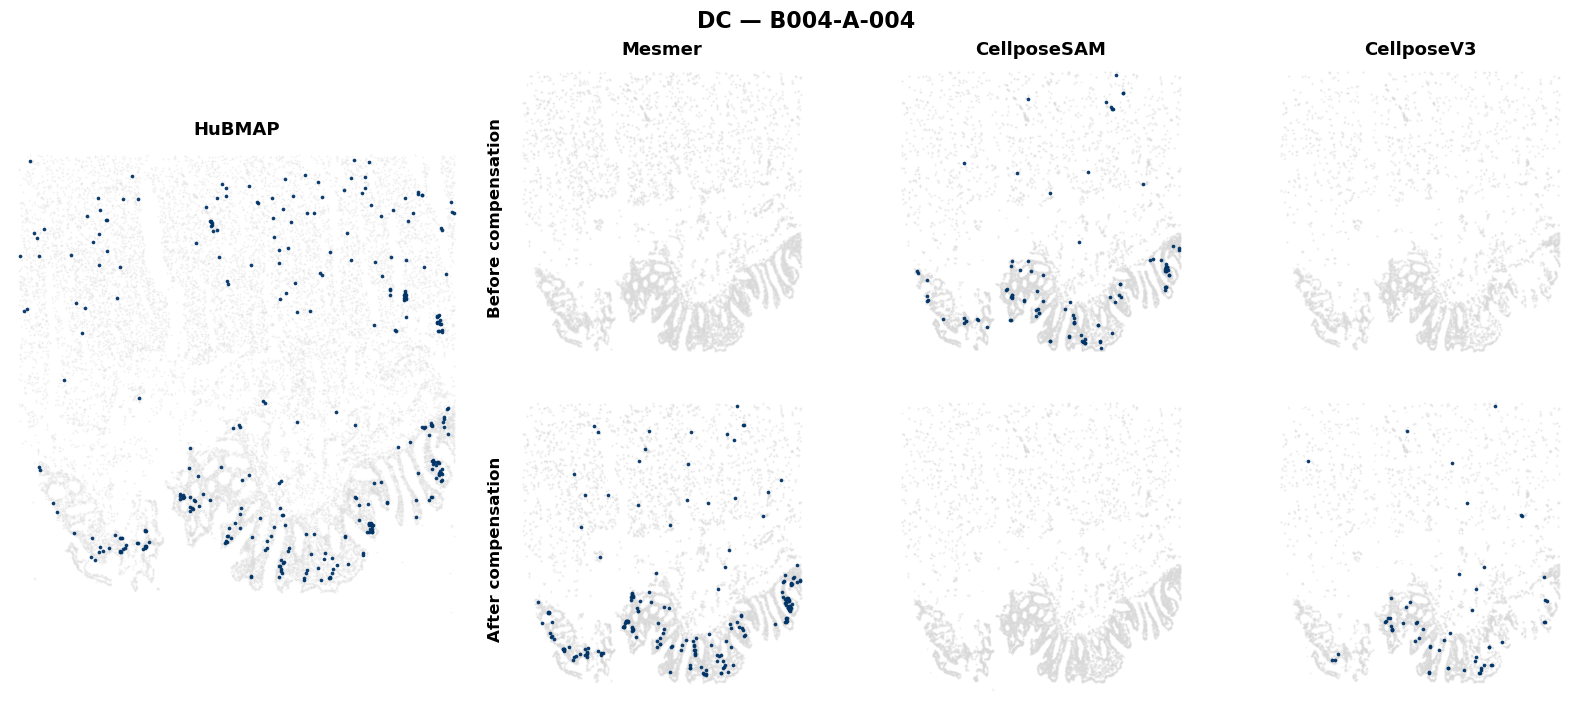

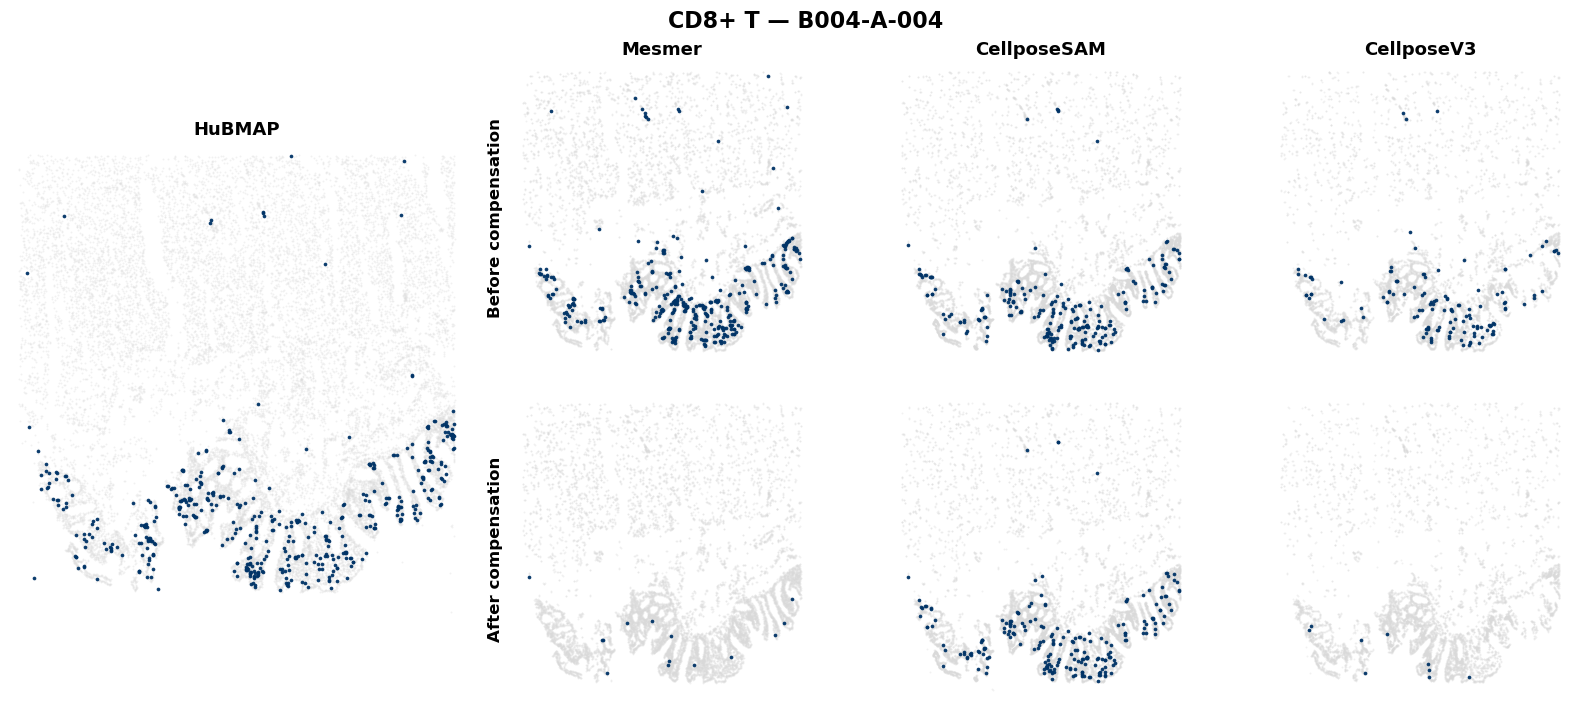

In [10]:

# ============================================================
# GENERATE FIGURE S02 PANELS
# ============================================================

for cell_type in CELL_TYPES_TO_PLOT:
    plot_spatial_comparison(
        slide=SLIDES_TO_PLOT[0],
        cell_type=cell_type,
    )
